In [2]:
# ==============================================================================
# CONFIGURACIÓN DE ENTORNO Y LIBRERÍAS (Tabla 1 de Metodología)
# ==============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import kendalltau
import matplotlib.pyplot as plt

# Configuración visual para gráficos (Estilo paper)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# ==============================================================================
# 1. DATOS, POBLACIÓN Y MUESTRA (2020 - 2024)
# ==============================================================================
print("1. Extrayendo datos de la BMV...")

pares_bmv = [
    'ASURB.MX', 'GAPB.MX', 'GFNORTEO.MX', 'GFINBURO.MX',
    'CEMEXCPO.MX', 'GCC.MX', 'FEMSAUBD.MX', 'AC.MX',
    'AMXB.MX', 'TLEVISACPO.MX', 'BIMBOA.MX', 'GRUMAB.MX',
    'WALMEX.MX', 'CHDRAUIB.MX', 'GMEXICOB.MX', 'PE&OLES.MX',
    'ALFA.MX', 'CUERVO.MX', 'BBAJIOO.MX', 'KOFUBL.MX'
]

# Descarga usando precios ajustados (auto_adjust=True)
datos_raw = yf.download(pares_bmv, start='2020-01-01', end='2024-12-31', auto_adjust=True)

# Priorizamos 'Adj Close' para asegurar que el análisis de rentabilidad sea correcto.
# Si no está disponible (dependiendo de la versión de yfinance), usamos 'Close'.
precios = datos_raw['Adj Close'] if 'Adj Close' in datos_raw.columns else datos_raw['Close']

print(f"Datos descargados exitosamente: {precios.shape[0]} días, {precios.shape[1]} activos.")

1. Extrayendo datos de la BMV...


[*********************100%***********************]  20 of 20 completed

Datos descargados exitosamente: 1274 días, 20 activos.


In [4]:
# ==============================================================================
# 2. LIMPIEZA Y TRANSFORMACIÓN A RETORNOS LOGARÍTMICOS (Eq. 1)
# ==============================================================================
print("2. Procesando y limpiando series de tiempo...")

# Forward fill para feriados y eliminación de nulos residuales
precios = precios.ffill().dropna()

# Cálculo de Retornos Logarítmicos (Estacionariedad)
retornos_log = np.log(precios / precios.shift(1)).dropna()

# Breve Análisis Exploratorio (EDA)
eda_stats = pd.DataFrame({
    'Media Diaria': retornos_log.mean(),
    'Volatilidad (Std)': retornos_log.std(),
    'Asimetría (Skew)': retornos_log.skew()
})
print("\nEstadísticas Descriptivas (Muestra):")
print(eda_stats.head())

2. Procesando y limpiando series de tiempo...

Estadísticas Descriptivas (Muestra):
            Media Diaria  Volatilidad (Std)  Asimetría (Skew)
Ticker                                                       
AC.MX           0.000580           0.014352          0.268602
ALFA.MX         0.000038           0.015637         -0.821336
AMXB.MX         0.000117           0.016168         -1.935456
ASURB.MX        0.000424           0.021408          0.433474
BBAJIOO.MX      0.000532           0.021948         -0.252437


In [5]:
# ==============================================================================
# 3. FASE 1: FORMACIÓN Y SELECCIÓN DE PARES (MÉTODO SSD - Eq. 2)
# ==============================================================================
print("\n3. Calculando Distancia Euclidiana (SSD)...")

# Normalizar precios al inicio del periodo (P_t / P_0)
precios_norm = precios / precios.iloc[0]

pares = [
    ('ASURB.MX', 'GAPB.MX'), ('GFNORTEO.MX', 'GFINBURO.MX'),
    ('CEMEXCPO.MX', 'GCC.MX'), ('FEMSAUBD.MX', 'AC.MX'),
    ('AMXB.MX', 'TLEVISACPO.MX'), ('BIMBOA.MX', 'GRUMAB.MX'),
    ('WALMEX.MX', 'CHDRAUIB.MX'), ('GMEXICOB.MX', 'PE&OLES.MX'),
    ('ALFA.MX', 'CUERVO.MX'), ('BBAJIOO.MX', 'KOFUBL.MX')
]

resultados_ssd = {}
for act1, act2 in pares:
    if act1 in precios_norm.columns and act2 in precios_norm.columns:
        # Ecuación de SSD
        ssd = np.sum((precios_norm[act1] - precios_norm[act2])**2)
        resultados_ssd[f"{act1}-{act2}"] = ssd

# Ordenar para encontrar el mejor par
mejor_par = sorted(resultados_ssd.items(), key=lambda item: item[1])[0]
act_U, act_V = mejor_par[0].split('-')

print(f"Mejor par seleccionado (Menor SSD): {act_U} y {act_V} con SSD={mejor_par[1]:.4f}")


3. Calculando Distancia Euclidiana (SSD)...
Mejor par seleccionado (Menor SSD): ASURB.MX y GAPB.MX con SSD=20.0703


In [6]:
# ==============================================================================
# 4. FASE 2: ESTIMACIÓN DE DEPENDENCIA Y DESEMPATE (Erdely, 2026)
# ==============================================================================
print("\n4. Aplicando corrección de empates y marginalización empírica...")

def desempate_erdely(v):
    """Añade ruido uniforme infinitesimal (Eq. 3 y 4) a retornos empatados."""
    vv = np.array(v, dtype=float).copy()
    v_series = pd.Series(vv)
    duplicados = v_series.duplicated(keep='first')
    ipos = v_series.index[duplicados].tolist()
    npos = len(ipos)

    if npos > 0:
        # Eq. 4: Cálculo del factor epsilon
        valores_no_cero = np.abs(vv[vv != 0])
        epsilon = np.min(valores_no_cero) / 1_000_000.0 if len(valores_no_cero) > 0 else 1e-10

        # Eq. 3: Ruido uniforme simétrico [-1, 1]
        ruido = epsilon * (2 * np.random.rand(npos) - 1)
        vv[ipos] += ruido

    return vv, npos

# Aplicar desempate al mejor par
ret_U_clean, empates_u = desempate_erdely(retornos_log[act_U].values)
ret_V_clean, empates_v = desempate_erdely(retornos_log[act_V].values)
print(f"Empates corregidos: {act_U} ({empates_u}), {act_V} ({empates_v})")

# Ecuación 5: Transformación a Pseudo-observaciones (EDF)
N = len(ret_U_clean)
# Usamos rankdata simulando la función indicadora 1(X <= x)
from scipy.stats import rankdata
u = rankdata(ret_U_clean) / (N + 1)
v = rankdata(ret_V_clean) / (N + 1)


4. Aplicando corrección de empates y marginalización empírica...
Empates corregidos: ASURB.MX (19), GAPB.MX (17)


In [7]:
# ==============================================================================
# 5. FASE 3: ESTIMACIÓN DE CÓPULA MIXTA (Optimización Algorítmica)
# ==============================================================================
print("\n5. Optimizando parámetros de la Cópula Mixta...")

# Cópula Empírica Bivariada (Cn)
cobs = np.column_stack((u, v))
def Cn(u_val, v_val, cobs):
    return np.sum((cobs[:, 0] <= u_val) & (cobs[:, 1] <= v_val)) / len(cobs)
C_empirica = np.array([Cn(ui, vi, cobs) for ui, vi in zip(u, v)])

# Familias Arquimedianas Base C(u,v)
def C_clayton(u, v, theta):
    return np.maximum((u**(-theta) + v**(-theta) - 1), 0)**(-1/theta)

def C_gumbel(u, v, theta):
    return np.exp(-((-np.log(u))**theta + (-np.log(v))**theta)**(1/theta))

def C_frank(u, v, theta):
    num = (np.exp(-theta*u) - 1) * (np.exp(-theta*v) - 1)
    den = np.exp(-theta) - 1
    return - (1/theta) * np.log(1 + num/den)

# Inicialización por Tau de Kendall (Eq. 7)
tau, _ = kendalltau(u, v)
theta_c_init = max(0.1, (2 * tau) / (1 - tau)) if tau > 0 else 0.1
theta_g_init = max(1.1, 1 / (1 - tau)) if tau > 0 else 1.1
theta_f_init = 2.0

# Función Objetivo (Minimizar distancia vs Cópula Empírica - Eq. 8)
def funcion_objetivo(pesos):
    w1, w2, w3 = pesos
    C_mix = (w1 * C_clayton(u, v, theta_c_init)) + \
            (w2 * C_gumbel(u, v, theta_g_init)) + \
            (w3 * C_frank(u, v, theta_f_init))
    return np.sum((C_mix - C_empirica)**2)

# Restricciones y Optimización (Suma de pesos = 1)
restricciones = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
limites = ((0, 1), (0, 1), (0, 1))
opt_result = minimize(funcion_objetivo, [0.33, 0.33, 0.34], method='SLSQP', bounds=limites, constraints=restricciones)

w_c, w_g, w_f = opt_result.x
print(f"Pesos Optimizados -> Clayton: {w_c:.3f} | Gumbel: {w_g:.3f} | Frank: {w_f:.3f}")


5. Optimizando parámetros de la Cópula Mixta...
Pesos Optimizados -> Clayton: 0.370 | Gumbel: 0.630 | Frank: 0.000



6. Generando señales de trading y ejecutando Backtest...
Rendimiento Acumulado Neto: 258.67%
Ratio de Sharpe Anualizado: 1.02


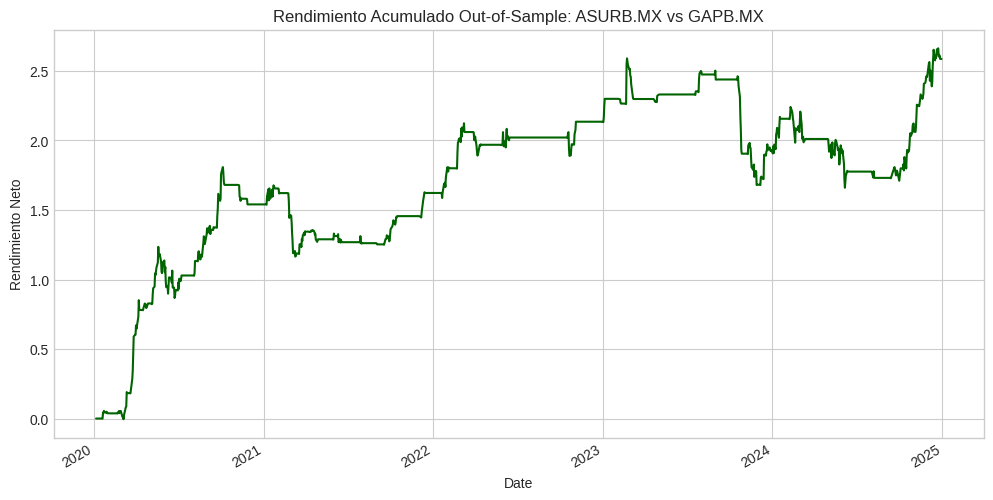

In [8]:
# ==============================================================================
# 6. FASE 4: MISPRICING INDEX Y BACKTESTING DE LA ESTRATEGIA
# ==============================================================================
print("\n6. Generando señales de trading y ejecutando Backtest...")

# Derivadas parciales dC/dv para el MI
def mi_clayton(u, v, theta):
    term = (u**-theta + v**-theta - 1)
    return v**(-theta - 1) * (term**(-1/theta - 1))

def mi_gumbel(u, v, theta):
    log_u, log_v = -np.log(u), -np.log(v)
    A = (log_u**theta + log_v**theta)**(1/theta)
    return np.exp(-A) * (log_v**(theta-1) / v) * (log_u**theta + log_v**theta)**(1/theta - 1)

def mi_frank(u, v, theta):
    num = np.exp(-theta * u) * (np.exp(-theta * v) - 1)
    den = (np.exp(-theta) - 1) + (np.exp(-theta * u) - 1) * (np.exp(-theta * v) - 1)
    return num / den

# Cálculo del MI Mixto (Eq. 9)
mi_mixto = (w_c * mi_clayton(u, v, theta_c_init)) + \
           (w_g * mi_gumbel(u, v, theta_g_init)) + \
           (w_f * mi_frank(u, v, theta_f_init))

# Lógica de señales de Trading (Umbrales 0.05, 0.95, 0.50)
df = pd.DataFrame({'MI': mi_mixto, 'Ret_U': ret_U_clean, 'Ret_V': ret_V_clean}, index=retornos_log.index)
df['Posicion'] = 0

# Iterar para abrir y cerrar posiciones
pos_actual = 0
for i in range(len(df)):
    mi = df['MI'].iloc[i]
    if mi >= 0.95: pos_actual = -1 # Venta en Corto U, Long V
    elif mi <= 0.05: pos_actual = 1  # Long U, Venta Corto V
    elif 0.45 <= mi <= 0.55: pos_actual = 0 # Zona de cierre (0.50 aprox)
    df.iloc[i, df.columns.get_loc('Posicion')] = pos_actual

# Rendimientos de la estrategia asumiendo costo de transacción (0.10%)
costo_tx = 0.0010
df['Cambio_Posicion'] = df['Posicion'].diff().fillna(0)
df['Costo_Transaccion'] = np.where(df['Cambio_Posicion'] != 0, costo_tx, 0)

# Retorno de la estrategia = Posición anterior * (Ret U - Ret V) - Costos
df['Ret_Estrategia'] = df['Posicion'].shift(1) * (df['Ret_U'] - df['Ret_V']) - df['Costo_Transaccion']
df['Ret_Acumulado'] = np.exp(df['Ret_Estrategia'].cumsum()) - 1

# Métricas de Riesgo (Sharpe Ratio)
rf_diaria = 0.05 / 252 # Tasa libre de riesgo (Cetes 5% aprox)
sharpe_ratio = (df['Ret_Estrategia'].mean() - rf_diaria) / df['Ret_Estrategia'].std() * np.sqrt(252)

print(f"Rendimiento Acumulado Neto: {df['Ret_Acumulado'].iloc[-1]:.2%}")
print(f"Ratio de Sharpe Anualizado: {sharpe_ratio:.2f}")

# Gráfica Final
df['Ret_Acumulado'].plot(title=f"Rendimiento Acumulado Out-of-Sample: {act_U} vs {act_V}", color='darkgreen')
plt.ylabel('Rendimiento Neto')
plt.show()


7. Ejecutando Análisis de Robustez (Top 5 Pares - Ventanas Móviles)...
Top 5 Pares Seleccionados para el Portafolio: [['ASURB.MX', 'GAPB.MX'], ['ALFA.MX', 'CUERVO.MX'], ['GFNORTEO.MX', 'GFINBURO.MX'], ['CEMEXCPO.MX', 'GCC.MX'], ['BIMBOA.MX', 'GRUMAB.MX']]

-> Procesando Ventana: Formación 2020-01-01 a 2021-01-01 | Trading 2021-01-04 a 2021-06-30
-> Procesando Ventana: Formación 2020-07-01 a 2021-07-01 | Trading 2021-07-01 a 2021-12-31
-> Procesando Ventana: Formación 2021-01-01 a 2022-01-01 | Trading 2022-01-03 a 2022-06-30
-> Procesando Ventana: Formación 2021-07-01 a 2022-07-01 | Trading 2022-07-01 a 2022-12-30
-> Procesando Ventana: Formación 2022-01-01 a 2023-01-01 | Trading 2023-01-02 a 2023-06-30
-> Procesando Ventana: Formación 2022-07-01 a 2023-07-01 | Trading 2023-07-03 a 2023-12-29
-> Procesando Ventana: Formación 2023-01-01 a 2024-01-01 | Trading 2024-01-02 a 2024-06-28
-> Procesando Ventana: Formación 2023-07-01 a 2024-07-01 | Trading 2024-07-01 a 2024-12-30

🏆 RESULTADOS 

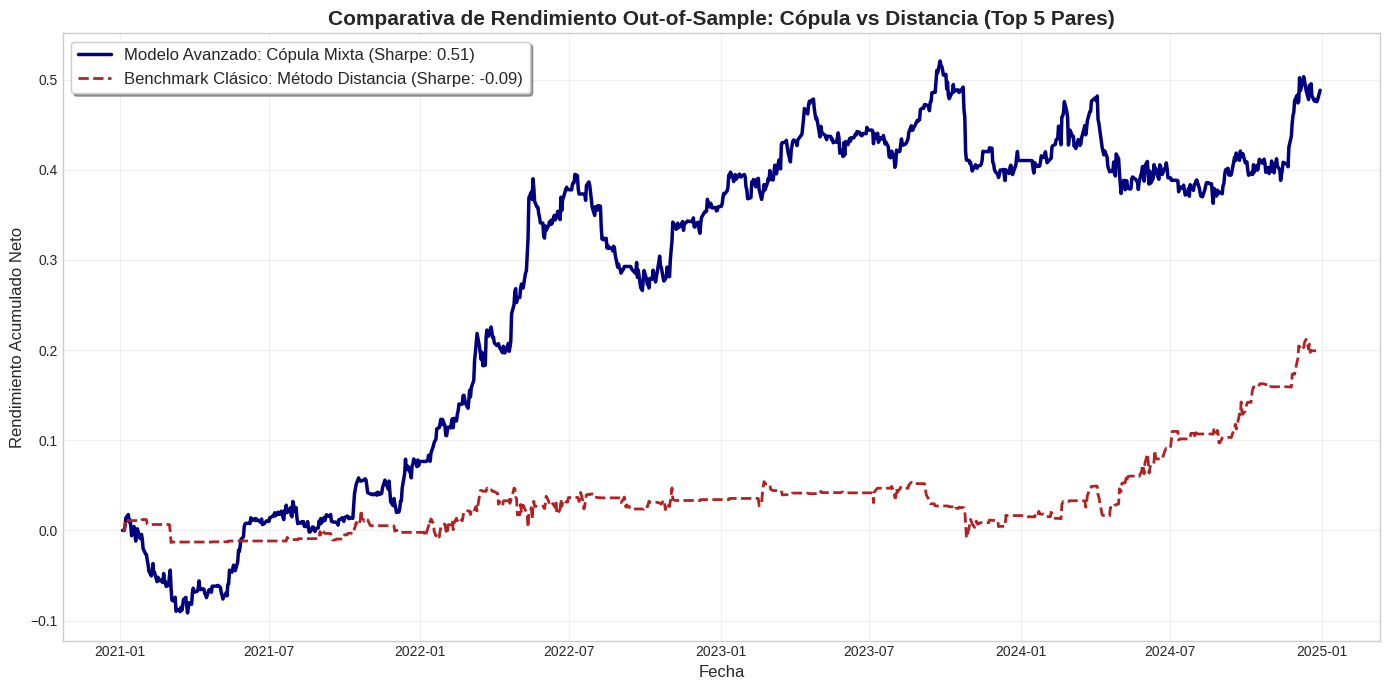

In [9]:
# ==============================================================================
# 7. ANÁLISIS ROBUSTO: PORTAFOLIO TOP 5 Y VENTANAS MÓVILES
# ==============================================================================
import warnings
warnings.filterwarnings("ignore") # Para evitar avisos de optimización en el loop

print("\n7. Ejecutando Análisis de Robustez (Top 5 Pares - Ventanas Móviles)...")

# 1. Seleccionar el Top 5 de Pares con menor SSD (De los resultados de la Fase 1)
top_5_pares = sorted(resultados_ssd.items(), key=lambda item: item[1])[:5]
pares_top5 = [par[0].split('-') for par in top_5_pares]
print(f"Top 5 Pares Seleccionados para el Portafolio: {pares_top5}\n")

# 2. Definir Fechas para las Ventanas Móviles (Ej. Semestrales desde 2021)
# Esto simula: 12 meses de formación hacia atrás, 6 meses de trading hacia adelante
fechas_corte = pd.date_range(start='2021-01-01', end='2024-12-31', freq='6MS')

# Diccionarios para guardar los rendimientos diarios de cada estrategia
retornos_portafolio_copula = pd.Series(dtype=float)
retornos_portafolio_distancia = pd.Series(dtype=float)

# 3. Bucle Principal del Tiempo (Ventanas Móviles)
for fecha_fin_formacion in fechas_corte:
    fecha_inicio_formacion = fecha_fin_formacion - pd.DateOffset(months=12)
    fecha_fin_trading = fecha_fin_formacion + pd.DateOffset(months=6) - pd.DateOffset(days=1)

    # Extraer datos de la ventana actual
    train_data = retornos_log.loc[fecha_inicio_formacion:fecha_fin_formacion]
    test_data = retornos_log.loc[fecha_fin_formacion:fecha_fin_trading]

    # Prevenir errores si los datos se acaban
    if test_data.empty or train_data.empty:
        continue

    print(f"-> Procesando Ventana: Formación {fecha_inicio_formacion.date()} a {fecha_fin_formacion.date()} | Trading {test_data.index[0].date()} a {test_data.index[-1].date()}")

    retornos_ventana_cop = pd.DataFrame(index=test_data.index)
    retornos_ventana_dist = pd.DataFrame(index=test_data.index)

    # Bucle Secundario: Evaluar cada par del Top 5 en esta ventana
    for act_U, act_V in pares_top5:

        # ---------------------------------------------------------
        # ESTRATEGIA 1: CÓPULA MIXTA
        # ---------------------------------------------------------
        # Desempate y EDF (Periodo de Formación)
        ret_U_train, _ = desempate_erdely(train_data[act_U].values)
        ret_V_train, _ = desempate_erdely(train_data[act_V].values)

        N_train = len(ret_U_train)
        u_train = rankdata(ret_U_train) / (N_train + 1)
        v_train = rankdata(ret_V_train) / (N_train + 1)

        # Optimización Cópula Mixta
        cobs = np.column_stack((u_train, v_train))
        C_emp = np.array([Cn(ui, vi, cobs) for ui, vi in zip(u_train, v_train)])

        tau, _ = kendalltau(u_train, v_train)
        tc_init = max(0.1, (2 * tau) / (1 - tau)) if tau > 0 else 0.1
        tg_init = max(1.1, 1 / (1 - tau)) if tau > 0 else 1.1
        tf_init = 2.0

        def obj_func(w):
            cmix = (w[0] * C_clayton(u_train, v_train, tc_init)) + \
                   (w[1] * C_gumbel(u_train, v_train, tg_init)) + \
                   (w[2] * C_frank(u_train, v_train, tf_init))
            return np.sum((cmix - C_emp)**2)

        opt = minimize(obj_func, [0.33, 0.33, 0.34], method='SLSQP', bounds=((0, 1),)*3, constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}))
        w_c, w_g, w_f = opt.x

        # Trading Out-of-Sample con Mispricing Index
        ret_U_test, _ = desempate_erdely(test_data[act_U].values)
        ret_V_test, _ = desempate_erdely(test_data[act_V].values)

        N_test = len(ret_U_test)
        u_test = rankdata(ret_U_test) / (N_test + 1)
        v_test = rankdata(ret_V_test) / (N_test + 1)

        mi_mix = (w_c * mi_clayton(u_test, v_test, tc_init)) + \
                 (w_g * mi_gumbel(u_test, v_test, tg_init)) + \
                 (w_f * mi_frank(u_test, v_test, tf_init))

        df_test = pd.DataFrame({'MI': mi_mix, 'Ret_U': ret_U_test, 'Ret_V': ret_V_test}, index=test_data.index)
        pos = 0
        pos_list = []
        for mi in df_test['MI']:
            if mi >= 0.95: pos = -1
            elif mi <= 0.05: pos = 1
            elif 0.45 <= mi <= 0.55: pos = 0
            pos_list.append(pos)

        # Restamos costo de transacción de 0.10% a los cruces
        df_test['Pos'] = pos_list
        costo_tx = 0.0010
        df_test['Cambio'] = df_test['Pos'].diff().fillna(0)
        df_test['Costo'] = np.where(df_test['Cambio'] != 0, costo_tx, 0)
        retornos_ventana_cop[f'{act_U}_{act_V}'] = df_test['Pos'].shift(1) * (df_test['Ret_U'] - df_test['Ret_V']) - df_test['Costo']

        # ---------------------------------------------------------
        # ESTRATEGIA 2: MÉTODO DE DISTANCIA (El Benchmark Clásico)
        # ---------------------------------------------------------
        # Calcular media y std del spread en el periodo de formación
        spread_train = train_data[act_U] - train_data[act_V]
        mu_spread = spread_train.mean()
        std_spread = spread_train.std()

        # Operar si el Z-score rompe 2 desviaciones estándar en el periodo de Trading
        spread_test = test_data[act_U] - test_data[act_V]
        z_score = (spread_test - mu_spread) / std_spread

        pos_dist = 0
        pos_list_dist = []
        for z in z_score:
            if z >= 2.0: pos_dist = -1
            elif z <= -2.0: pos_dist = 1
            elif -0.5 <= z <= 0.5: pos_dist = 0
            pos_list_dist.append(pos_dist)

        df_dist = pd.DataFrame({'Pos': pos_list_dist, 'Ret_U': test_data[act_U], 'Ret_V': test_data[act_V]}, index=test_data.index)
        df_dist['Cambio'] = df_dist['Pos'].diff().fillna(0)
        df_dist['Costo'] = np.where(df_dist['Cambio'] != 0, costo_tx, 0)
        retornos_ventana_dist[f'{act_U}_{act_V}'] = df_dist['Pos'].shift(1) * (df_dist['Ret_U'] - df_dist['Ret_V']) - df_dist['Costo']

    # Promediar los rendimientos de los 5 pares (Diversificación de Portafolio)
    retornos_portafolio_copula = pd.concat([retornos_portafolio_copula, retornos_ventana_cop.mean(axis=1).fillna(0)])
    retornos_portafolio_distancia = pd.concat([retornos_portafolio_distancia, retornos_ventana_dist.mean(axis=1).fillna(0)])

# Limpiar posibles días duplicados por el traslape de las ventanas de trading
retornos_portafolio_copula = retornos_portafolio_copula[~retornos_portafolio_copula.index.duplicated(keep='first')]
retornos_portafolio_distancia = retornos_portafolio_distancia[~retornos_portafolio_distancia.index.duplicated(keep='first')]

# 4. Cálculo de Métricas Finales y Gráfica Maestra
sharpe_copula = (retornos_portafolio_copula.mean() - rf_diaria) / retornos_portafolio_copula.std() * np.sqrt(252)
sharpe_distancia = (retornos_portafolio_distancia.mean() - rf_diaria) / retornos_portafolio_distancia.std() * np.sqrt(252)

eq_copula = np.exp(retornos_portafolio_copula.cumsum()) - 1
eq_distancia = np.exp(retornos_portafolio_distancia.cumsum()) - 1

print("\n" + "="*55)
print(" RESULTADOS FINALES: PORTAFOLIO TOP 5 (OUT-OF-SAMPLE) ")
print("="*55)
print(f"Ratio de Sharpe (Cópula Mixta):     {sharpe_copula:.2f}")
print(f"Ratio de Sharpe (Método Distancia): {sharpe_distancia:.2f}")
print(f"Rendimiento Acumulado Cópula:       {eq_copula.iloc[-1]:.2%}")
print(f"Rendimiento Acumulado Distancia:    {eq_distancia.iloc[-1]:.2%}")

plt.figure(figsize=(14, 7))
plt.plot(eq_copula.index, eq_copula, label=f'Modelo Avanzado: Cópula Mixta (Sharpe: {sharpe_copula:.2f})', color='navy', linewidth=2.5)
plt.plot(eq_distancia.index, eq_distancia, label=f'Benchmark Clásico: Método Distancia (Sharpe: {sharpe_distancia:.2f})', color='firebrick', linestyle='--', linewidth=2)
plt.title('Comparativa de Rendimiento Out-of-Sample: Cópula vs Distancia (Top 5 Pares)', fontsize=15, fontweight='bold')
plt.ylabel('Rendimiento Acumulado Neto', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()